# P05 — The ML Mindset  *(the first temptation: to memorise)*

> **The story so far.** We've fed the mind its first meal ([P04](P04_Data_and_Visualization.ipynb)) —
> clean features `X` and answers `y`. Now it sits down for its first real lesson. And here it faces
> the oldest temptation of every student: the night before an exam, you can either *understand* the
> material or just *cram the answer key*. Cramming feels like genius — you ace the practice test —
> right up until the real exam asks something new and you fall apart. A mind does exactly this; we
> call it **overfitting**, and it is the central villain of all of machine learning. Today we set up
> the frame every later algorithm plugs into, then catch the mind red-handed memorising — and learn
> the discipline that forces it to truly understand instead.

Foundations done — now we build models. But first the *mindset*, because every algorithm in this
playbook (linear regression, neural nets, transformers) is the **same shape**:

> Learning = find a function `f` with adjustable numbers (**parameters**) so that `f(input) ≈ correct output`,
> by minimising a **loss** on **data** using gradient descent.

You already met every piece: the function is matrix-multiplies (P01), the loss is cross-entropy or
MSE (P03), and the minimiser is gradient descent (P02). This notebook names the workflow around
them and introduces the one thing that ruins models if ignored: **overfitting**. We'll *see* it
happen with real numbers.

## B1 — Supervised vs unsupervised: two kinds of learning

A child can learn two ways. With a flash-card deck — picture on the front, the word on the back —
every example comes with its answer; that's **supervised** learning. Or, dropped into a bin of
mixed toys with no labels at all, the child still notices that blocks group with blocks and cars
with cars; that's **unsupervised** learning, finding structure with nobody handing over answers.

- **Supervised** — data comes with the right answers (**labels**). You learn input → output.
  - *Regression*: predict a number (house price). *Classification*: predict a category (spam / not).
- **Unsupervised** — no labels; you find structure. *Clustering* (group similar customers),
  *dimensionality reduction* (compress features, P09's PCA).

A GPT is (self-)supervised: the "label" for each position is simply *the next token in the text* —
the data labels itself, which is why we can train on raw text.

| | has labels? | goal | example |
|---|---|---|---|
| Regression | yes | predict a number | income → spending |
| Classification | yes | predict a category | email → spam? |
| Clustering | no | group similar items | customer segments |
| Dim. reduction | no | compress / visualise | 100 features → 2 |

## B2 — Features, labels, and the data matrix

When a bank decides on a mortgage, it lines up the facts it's allowed to look at — income, the
home's size, number of bedrooms — and the one thing it's trying to predict: the price (or whether
you'll repay). The facts it looks at are the **features**; the thing it predicts is the **label**.
Fix this vocabulary once and it never goes fuzzy again, because every model the mind ever runs uses
it.

The vocabulary, fixed once so it's never fuzzy again:
- **`X`** — the **features**, shape `(n_samples, n_features)`. One row per example.
- **`y`** — the **labels**, shape `(n_samples,)`. One answer per example.
- A **model** maps a row of `X` to a prediction; **training** tunes its parameters so predictions
  match `y`.

**Worked example by hand.** 3 houses, features `[size(1000 sqft), bedrooms]`, label `price($100k)`:
```
        size  beds        price
house0 [ 1.0,  2 ]         2.0
house1 [ 1.5,  3 ]         3.0
house2 [ 2.0,  3 ]         3.5
```
So `X` is `(3, 2)` and `y` is `(3,)`. A linear model would guess `price ≈ w0·size + w1·beds + b`.

In [1]:
import numpy as np
X = np.array([[1.0, 2],
              [1.5, 3],
              [2.0, 3]])
y = np.array([2.0, 3.0, 3.5])
print("X (features) shape", X.shape, "-> 3 samples, 2 features each")
print("y (labels)   shape", y.shape, "->", y)

# a model is just parameters + a rule. Try a hand-guessed linear model:
w = np.array([1.0, 0.5]); b = 0.0
pred = X @ w + b                       # one matmul (P01!) gives all 3 predictions
print("\nguessed w =", w, " b =", b)
print("predictions :", pred, " vs true", y)
print("(training, next notebook, will FIND good w and b instead of guessing)")

X (features) shape (3, 2) -> 3 samples, 2 features each
y (labels)   shape (3,) -> [2.  3.  3.5]

guessed w = [1.  0.5]  b = 0.0
predictions : [2.  3.  3.5]  vs true [2.  3.  3.5]
(training, next notebook, will FIND good w and b instead of guessing)


## B3 — The cardinal rule: train / validation / test split

No honest teacher puts the exact homework problems on the final exam — that would measure who
memorised, not who learned. So we hold some questions back. The homework the mind studies from is
the **training set**; a small quiz we use to tune how it studies is the **validation set**; and a
sealed final exam, opened exactly once, is the **test set**. Peek at that final early and every
score it earns becomes a comforting lie.

If you test a model on the same data it learned from, you measure **memorisation**, not learning —
like grading an exam with the answer key the student studied. So we split the data:

- **Train** (~70%) — the model fits its parameters on this.
- **Validation** (~15%) — we tune *settings* (learning rate, model size) by checking here.
- **Test** (~15%) — touched **once**, at the very end, to estimate real-world performance.

The golden rule: **never let the model see test data during training or tuning.** Breaking it is
"data leakage" and produces lying-good scores that collapse in production.

In [2]:
import numpy as np
from sklearn.model_selection import train_test_split

X = np.arange(20).reshape(10, 2)      # 10 fake samples, 2 features
y = np.arange(10)

X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.4, random_state=0)
X_val, X_test, y_val, y_test   = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=0)

print("total samples :", len(X))
print("train         :", len(X_train), "(fit parameters here)")
print("validation    :", len(X_val),   "(tune settings here)")
print("test          :", len(X_test),  "(judge ONCE here)")

total samples : 10
train         : 6 (fit parameters here)
validation    : 2 (tune settings here)
test          : 2 (judge ONCE here)


## B4 — Overfitting: the central villain, shown with real numbers

Now we catch the mind cheating, with real numbers. Think of two bad students. One barely studied and
gives the same vague answer to everything — too simple, wrong everywhere; that's **underfitting**.
The other memorised every practice question word-for-word, *including the typos* — flawless on the
homework, lost the moment a question is rephrased; that's **overfitting**. The wise student sits
between them. Watch the gap open up below: it *is* overfitting, made of numbers you can read.

**Underfitting** = model too simple, misses the pattern (high error everywhere). **Overfitting** =
model too complex, *memorises* the training points including their noise, so it nails training data
but fails on new data. The sweet spot is in between.

We'll fit polynomials of increasing **degree** to 8 noisy points from a gentle curve. Degree 1 (a
line) underfits; a very high degree wiggles through every training point (train error → ~0) but
goes haywire between them, so **test error blows up**. Watch the two error columns diverge — that
gap *is* overfitting.

In [3]:
import numpy as np
rng = np.random.default_rng(0)

# true relationship is a gentle quadratic; we observe it with noise
f_true = lambda x: 0.5*x**2 - x + 2
x_train = np.linspace(-3, 3, 8)
y_train = f_true(x_train) + rng.normal(0, 1.0, size=8)     # noisy observations
x_test  = np.linspace(-3, 3, 50)
y_test  = f_true(x_test)                                    # clean truth to judge against

print(f"{'degree':>6} {'train_MSE':>10} {'test_MSE':>10}   verdict")
for degree in [1, 2, 5, 7]:
    coeffs = np.polyfit(x_train, y_train, degree)          # fit polynomial
    train_mse = np.mean((np.polyval(coeffs, x_train) - y_train)**2)
    test_mse  = np.mean((np.polyval(coeffs, x_test)  - y_test )**2)
    verdict = ("underfit" if degree==1 else
               "good fit" if degree==2 else
               "OVERFIT — memorised noise")
    print(f"{degree:>6} {train_mse:>10.3f} {test_mse:>10.3f}   {verdict}")
print("\nnote: train error keeps falling with degree, but test error U-turns up. That U is overfitting.")

degree  train_MSE   test_MSE   verdict
     1      3.765      2.544   underfit
     2      0.167      0.204   good fit
     5      0.021      0.507   OVERFIT — memorised noise
     7      0.000      0.412   OVERFIT — memorised noise

note: train error keeps falling with degree, but test error U-turns up. That U is overfitting.


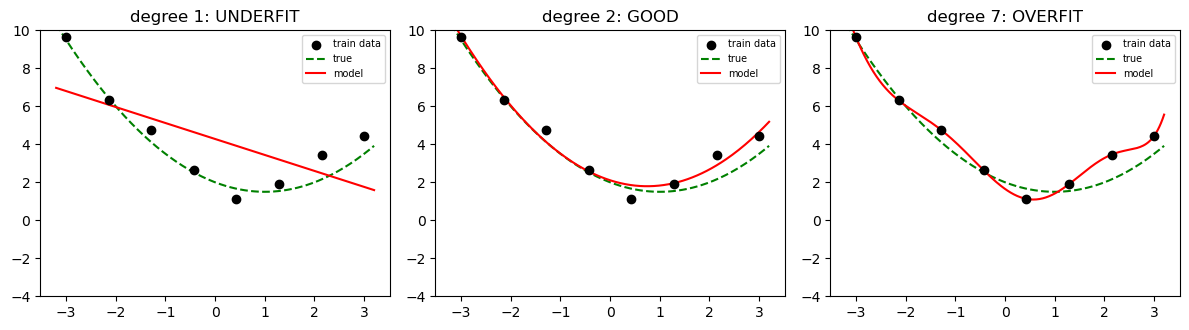

degree 7 (red) threads every black dot but wiggles wildly away from the green truth.


In [4]:
import numpy as np, matplotlib.pyplot as plt
rng = np.random.default_rng(0)
f_true = lambda x: 0.5*x**2 - x + 2
x_train = np.linspace(-3, 3, 8); y_train = f_true(x_train) + rng.normal(0,1.0,size=8)
xx = np.linspace(-3.2, 3.2, 200)

fig, ax = plt.subplots(1, 3, figsize=(12, 3.4))
for a, degree, title in zip(ax, [1, 2, 7], ["degree 1: UNDERFIT", "degree 2: GOOD", "degree 7: OVERFIT"]):
    c = np.polyfit(x_train, y_train, degree)
    a.scatter(x_train, y_train, c="black", zorder=3, label="train data")
    a.plot(xx, f_true(xx), "g--", label="true")
    a.plot(xx, np.polyval(c, xx), "r", label="model")
    a.set_title(title); a.set_ylim(-4, 10); a.legend(fontsize=7)
plt.tight_layout(); plt.show()
print("degree 7 (red) threads every black dot but wiggles wildly away from the green truth.")

## Recap — the ML workflow

| Step | What | Notebook |
|------|------|----------|
| 1. Get data → `X, y` | features and labels | P04 |
| 2. Split | train / val / test | B3 |
| 3. Pick a model | `f` with parameters | Part 1 & 2 |
| 4. Train | minimise loss via gradient descent | P02, P06 |
| 5. Validate | tune settings, watch for overfitting | B4 |
| 6. Test once | honest final score | B3 |

## Common mistakes
1. **Testing on training data.** The #1 sin — gives lying-good scores. Always hold out a test set.
2. **Peeking at the test set** to pick settings. That silently leaks it into the model.
3. **Equating low training error with a good model.** Overfit models have *zero* training error and useless predictions.
4. **More complexity is not better.** The right capacity matches the true pattern; beyond it you fit noise.
5. **Normalising/imputing using whole-dataset stats.** Compute them on *train* only, then apply to val/test.

## Exercises (do them in new code cells)
1. In B4, add `degree=3` and `degree=10`. Where is test error lowest? Is that the true degree?
2. Increase the noise (`rng.normal(0, 3.0, ...)`). Does overfitting get easier or harder to trigger?
3. Give the model more data (`np.linspace(-3,3,40)`). Does the degree-7 fit overfit less? Why?
4. Classify each as regression/classification/clustering: predicting tomorrow's temperature; tagging emails spam/not; grouping songs by sound.
5. Why can a GPT train on raw text with no human labels? (Hint: what is the "answer" at each position?)

---

**The mind now knows the shape of every lesson — and the temptation it must resist.** So far we've
only *guessed* its parameters by hand. Next, in
[P06 — Linear Regression from scratch](P06_Linear_Regression.ipynb), the mind takes its very first
*reflex*: it stops guessing and actually **learns** `w` and `b` for itself — the heartbeat of P02
(predict → measure → step downhill) beating for real, on real data.